# Monitoring Amazonas Deforestation with UP42 and Sentinel-2

## Objective

This notebook demonstrates a repeatable prototype workflow for monitoring potential deforestation in the Amazonas region using Sentinel-2 imagery through the UP42 platform.

The workflow covers:
- authentication with the UP42 API
- AOI definition using a polygon in Amazonas
- Sentinel-2 catalog search with time and cloud filtering
- ordering selected scenes
- STAC-based inspection of delivered assets in storage
- NDVI computation for two timestamps
- NDVI difference mapping to highlight potential vegetation change

## Why this workflow?

The goal is to reflect a realistic support-oriented customer workflow:
1. discover suitable imagery
2. order the selected data
3. inspect the delivery through STAC
4. retrieve the raster assets
5. compute an interpretable vegetation index
6. visualize change in a reproducible way

In [1]:
# Imports
import json
import os
import uuid
import zipfile
from pathlib import Path

import geojson
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from dotenv import load_dotenv
import up42

## Configuration

The parameters below are grouped in one place so the workflow is easy to review and modify.

This improves readability and makes the logic of the notebook more obvious:
- date range
- cloud threshold
- collection and data product names
- output naming
- tracking settings

In [2]:
# ----------------------------
# Configuration
# ----------------------------

START_DATE = "2024-06-01"
END_DATE = "2024-12-31"
MAX_CLOUD_COVER = 10

COLLECTION_NAME = "sentinel-2"
DATA_PRODUCT_NAME = "sentinel-2-level-2a"

TITLE_PREFIX = "amazonas-deforestation"
TAGS = ["up42-challenge", "sentinel-2", "amazonas"]

REPORT_TIME_SECONDS = 60

## Project paths

This section defines the main project folders and creates output directories if they do not already exist.

Using explicit paths helps keep the notebook reproducible and avoids confusion when running it from different working directories.

In [3]:
# ----------------------------
# Project paths
# ----------------------------

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
AOI_DIR = DATA_DIR / "aoi"
DOWNLOAD_DIR = DATA_DIR / "downloads"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"

DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DOWNLOAD_DIR:", DOWNLOAD_DIR)
print("FIG_DIR:", FIG_DIR)

PROJECT_ROOT: /Users/elnidow/up42-amazonas-deforestation
DOWNLOAD_DIR: /Users/elnidow/up42-amazonas-deforestation/data/downloads
FIG_DIR: /Users/elnidow/up42-amazonas-deforestation/outputs/figures


## Authentication

Credentials are loaded from a local `.env` file instead of being hardcoded into the notebook.

In [4]:
# ----------------------------
# Load credentials and authenticate
# ----------------------------

load_dotenv(PROJECT_ROOT / ".env")

UP42_USERNAME = os.getenv("UP42_USERNAME")
UP42_PASSWORD = os.getenv("UP42_PASSWORD")

if not UP42_USERNAME or not UP42_PASSWORD:
    raise ValueError(
        "Missing UP42 credentials. Please add UP42_USERNAME and UP42_PASSWORD to your .env file."
    )

up42.authenticate(
    username=UP42_USERNAME,
    password=UP42_PASSWORD
)

print("Authenticated successfully.")

2026-04-04 17:02:43,985 - Authentication with UP42 successful!


Authenticated successfully.


## Why Sentinel-2 Level-2A?

UP42 provides Sentinel-2 as a free medium-resolution multispectral collection with data from 2017 to the present. The `sentinel-2-level-2a` product is orthorectified surface reflectance imagery, which is well suited for vegetation-index analysis such as NDVI

## Area of Interest (AOI)

The AOI is stored as a local GeoJSON file. Keeping the AOI in a separate file makes the notebook cleaner and allows the same workflow to be reused with a different polygon later.

A small AOI is used here to keep catalog search, ordering, and raster processing compact and reproducible.

In [5]:
# ----------------------------
# Load AOI
# ----------------------------

aoi_path = AOI_DIR / "amazonas_aoi.geojson"
aoi_gdf = gpd.read_file(aoi_path)

if aoi_gdf.empty:
    raise ValueError("AOI file was loaded, but it contains no features.")

if len(aoi_gdf) != 1:
    raise ValueError("Expected exactly one AOI feature in the GeoJSON file.")

display(aoi_gdf)

# Convert the AOI into a GeoJSON geometry dictionary for UP42 search/order operations
aoi_geometry = json.loads(aoi_gdf.to_json())["features"][0]["geometry"]

print(json.dumps(aoi_geometry, indent=2))

,name,geometry
0,amazonas_test_aoi,"POLYGON ((-62.3 -3.1, -62.3 -3, -62.15 -3, -62..."


{
  "type": "Polygon",
  "coordinates": [
    [
      [
        -62.3,
        -3.1
      ],
      [
        -62.3,
        -3.0
      ],
      [
        -62.15,
        -3.0
      ],
      [
        -62.15,
        -3.1
      ],
      [
        -62.3,
        -3.1
      ]
    ]
  ]
}


## Product discovery

Before using a data product, the notebook checks the available archive collections in the UP42 glossary and then selects the Sentinel-2 collection and the Level-2A product.

This makes the workflow more transparent and avoids relying on hidden assumptions.

In [6]:
# ----------------------------
# Retrieve archive collections
# ----------------------------

archive_collections = up42.ProductGlossary.get_collections(
    collection_type=up42.CollectionType.ARCHIVE,
    sort_by=up42.CollectionSorting.name.asc
)

sentinel_collection = next(
    (c for c in archive_collections if c.name == COLLECTION_NAME),
    None
)

if sentinel_collection is None:
    raise ValueError(f"{COLLECTION_NAME} collection not found.")

print("Collection:", sentinel_collection.name)

print("\nAvailable data products:")
for dp in sentinel_collection.data_products:
    print("-", dp.name)

print("\nAvailable providers:")
for p in sentinel_collection.providers:
    print("-", p.name, "| host:", p.is_host)

# Select the specific data product required for ordering
data_product = next(
    (dp for dp in sentinel_collection.data_products if dp.name == DATA_PRODUCT_NAME),
    None
)

if data_product is None:
    raise ValueError(f"{DATA_PRODUCT_NAME} data product not found.")

print("\nSelected data product:", data_product.name)
print("Data product ID:", data_product.id)

# Select the host provider used for searching the collection
host = next((p for p in sentinel_collection.providers if p.is_host), None)

if host is None:
    raise ValueError("No host provider found for Sentinel-2 collection.")

print("Selected host provider:", host.name)

Collection: sentinel-2

Available data products:
- sentinel-2-level-2a

Available providers:
- earthsearch-aws | host: True
- esa | host: False

Selected data product: sentinel-2-level-2a
Data product ID: c3de9ed8-f6e5-4bb5-a157-f6430ba756da
Selected host provider: earthsearch-aws


## Why NDVI?

NDVI is a simple and widely used vegetation index defined as:

NDVI = (NIR - Red) / (NIR + Red)

For Sentinel-2, Band 8 (B08) provides near-infrared information and Band 4 (B04) provides red reflectance

To keep the prototype simple and interpretable, two low-cloud Sentinel-2 scenes were selected from different timestamps. This satisfies the challenge requirement while keeping the workflow easy to audit and troubleshoot.

### Note on order placement and access prerequisites

Catalog search can succeed even when ordering is blocked by account-level prerequisites.  
During testing, order placement initially failed because the required EULA had not yet been accepted in the UP42 Console. After accepting the pending EULA in the workspace settings, the order workflow could proceed normally.

This is an important support consideration because customer issues at the ordering stage may be related to entitlement or legal acceptance settings rather than code logic.

## Catalog search

The search is constrained by:
- the AOI polygon
- a defined time range
- maximum cloud coverage

This is the first filtering step. It improves the chances of retrieving useful vegetation information, though it does not guarantee cloud-free pixels within the AOI.

In [7]:
# ----------------------------
# Search the catalog
# ----------------------------

search_results = list(
    host.search(
        collections=[COLLECTION_NAME],
        intersects=aoi_geometry,
        start_date=START_DATE,
        end_date=END_DATE,
        query={"cloudCoverage": {"LT": MAX_CLOUD_COVER}}
    )
)

scenes = search_results

print(f"Found {len(scenes)} scenes.")

if not scenes:
    raise ValueError(
        f"No scenes found for AOI, date range {START_DATE} to {END_DATE}, "
        f"and cloud cover < {MAX_CLOUD_COVER}%. Try widening the search."
    )

Found 6 scenes.


## Search result summary

The search results are converted into a small table so scene selection is transparent and easy to review.

This makes the logic of the scene choice explicit rather than hidden in the code.

In [8]:
# ----------------------------
# Build a table of scene metadata
# ----------------------------

records = []
for item in scenes:
    records.append({
        "id": getattr(item, "id", None),
        "datetime": getattr(item, "datetime", None),
        "cloudCoverage": getattr(item, "cloud_coverage", None) or getattr(item, "cloudCoverage", None),
        "provider": getattr(item, "provider", None)
    })

scenes_df = (
    pd.DataFrame(records)
    .sort_values("datetime")
    .reset_index(drop=True)
)

display(scenes_df)

,id,datetime,cloudCoverage,provider
0,S2A_T20MNB_20240708T142716_L2A,2024-07-08T14:33:45Z,5.296824,None
1,S2A_T20MNB_20240728T142957_L2A,2024-07-28T14:33:44Z,1.571829,None
2,S2A_T20MNB_20240807T143314_L2A,2024-08-07T14:33:42Z,0.001825,None
3,S2A_T20MNB_20240817T142712_L2A,2024-08-17T14:33:42Z,0.666877,None
4,S2B_T20MNB_20240822T143214_L2A,2024-08-22T14:33:40Z,1.192477,None
5,S2A_T20MNB_20241105T142709_L2A,2024-11-05T14:33:38Z,8.813514,None


## Scene selection

To keep the prototype simple and interpretable, two scenes are selected from the filtered result set.

Here, the earliest and latest suitable scenes are used to maximize temporal contrast while staying within the same filtered search result set.

In [9]:
# ----------------------------
# Select two scenes
# ----------------------------

scene_1_idx = 0
scene_2_idx = len(scenes_df) - 1

scene_1_id = scenes_df.loc[scene_1_idx, "id"]
scene_2_id = scenes_df.loc[scene_2_idx, "id"]

scene_1 = next(s for s in scenes if s.id == scene_1_id)
scene_2 = next(s for s in scenes if s.id == scene_2_id)

print("Scene 1")
print("ID:", scene_1.id)
print("Datetime:", scene_1.datetime)
print("Cloud coverage:", getattr(scene_1, "cloud_coverage", None) or getattr(scene_1, "cloudCoverage", None))

print("\nScene 2")
print("ID:", scene_2.id)
print("Datetime:", scene_2.datetime)
print("Cloud coverage:", getattr(scene_2, "cloud_coverage", None) or getattr(scene_2, "cloudCoverage", None))

Scene 1
ID: S2A_T20MNB_20240708T142716_L2A
Datetime: 2024-07-08T14:33:45Z
Cloud coverage: 5.296824

Scene 2
ID: S2A_T20MNB_20241105T142709_L2A
Datetime: 2024-11-05T14:33:38Z
Cloud coverage: 8.813514


## Order preparation

At this stage, the selected scenes are converted into UP42 order templates using:
- the chosen data product
- the AOI geometry
- the selected scene IDs
- unique display names for later identification in storage

Unique titles are useful because they make STAC lookup easier after the order is fulfilled.

In [10]:
# ----------------------------
# Helper function: create an order template
# ----------------------------

def make_order_template(scene, geometry, data_product, title_prefix=TITLE_PREFIX):
    # The AOI must be wrapped as a FeatureCollection for the order template
    aoi = geojson.FeatureCollection(
        features=[geojson.Feature(geometry=geometry)]
    )

    # Unique order titles help locate the matching output later in STAC storage
    unique_title = f"{title_prefix}-{scene.id}-{uuid.uuid4().hex[:8]}"

    order_template = up42.BatchOrderTemplate(
        data_product_id=data_product.id,
        display_name=unique_title,
        features=aoi,
        params={"id": scene.id},
        tags=TAGS
    )
    return order_template, unique_title

In [11]:
# ----------------------------
# Create order templates for the two selected scenes
# ----------------------------

order_template_1, order_title_1 = make_order_template(scene_1, aoi_geometry, data_product)
order_template_2, order_title_2 = make_order_template(scene_2, aoi_geometry, data_product)

print("Order title 1:", order_title_1)
print("Order title 2:", order_title_2)

Order title 1: amazonas-deforestation-S2A_T20MNB_20240708T142716_L2A-293226f1
Order title 2: amazonas-deforestation-S2A_T20MNB_20241105T142709_L2A-c5448143


## Estimate check

Before placing the orders, the notebook checks the estimates for both order templates.

This is a useful validation step before submitting requests to the platform.

In [12]:
# ----------------------------
# Inspect order estimates
# ----------------------------

print("Estimate 1:", order_template_1.estimate)
print("Estimate 2:", order_template_2.estimate)

Estimate 1: Estimate(items=[OrderCost(index=0, credits=0, size=8696.94, unit='SQ_KM')], credits=0, size=8696.94, unit='SQ_KM')
Estimate 2: Estimate(items=[OrderCost(index=0, credits=0, size=8609.56, unit='SQ_KM')], credits=0, size=8609.56, unit='SQ_KM')


## Note on order prerequisites

Catalog search can succeed even when ordering is blocked by workspace-level prerequisites such as EULA acceptance.

If order placement fails with a message about an unaccepted EULA, the required agreement must be accepted in the UP42 Console before the workflow can continue.

In [13]:
# ----------------------------
# Helper function: place an order
# ----------------------------

def place_order(order_template, label):
    try:
        order_refs = order_template.place()
        order = order_refs[0].order
        print(f"{label} order placed successfully.")
        print("Order ID:", order.id)
        print("Status:", order.status)
        return order
    except Exception as e:
        raise RuntimeError(f"{label} order placement failed: {e}") from e

In [14]:
# ----------------------------
# Place both orders
# ----------------------------

order_1 = place_order(order_template_1, "Scene 1")
order_2 = place_order(order_template_2, "Scene 2")

Scene 1 order placed successfully.
Order ID: c87b23e2-21a1-4072-9a21-fce3aa1be122
Status: BEING_PLACED
Scene 2 order placed successfully.
Order ID: 2b251991-bbad-4a93-890f-884b96f69e04
Status: BEING_PLACED


In [15]:
# ----------------------------
# Helper function: track order until terminal state
# ----------------------------

def track_order(order, label, report_time=REPORT_TIME_SECONDS):
    print(f"Tracking {label}...")
    order.track(report_time=report_time)
    print(f"{label} final status: {order.status} | fulfilled: {order.is_fulfilled}")

    if not order.is_fulfilled:
        raise RuntimeError(f"{label} did not complete successfully.")

In [16]:
# ----------------------------
# Track both orders
# ----------------------------

track_order(order_1, "Scene 1 order")
track_order(order_2, "Scene 2 order")

2026-04-04 17:10:37,170 - Tracking order updates, reporting every 60 seconds...
2026-04-04 17:10:37,224 - Order is BEING_PLACED! - c87b23e2-21a1-4072-9a21-fce3aa1be122


Tracking Scene 1 order...


2026-04-04 17:11:37,283 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:12:37,361 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:13:37,553 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:14:37,627 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:15:37,692 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:16:37,756 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:17:37,829 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:18:38,030 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:19:38,100 - Order is BEING_FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:20:38,164 - Order is FULFILLED! - c87b23e2-21a1-4072-9a21-fce3aa1be122
2026-04-04 17:20:38,166 - Tracking order updates, reporting every 60 seconds...
2026-04-04 17:20

Scene 1 order final status: FULFILLED | fulfilled: True
Tracking Scene 2 order...


2026-04-04 17:21:38,277 - Order is FULFILLED! - 2b251991-bbad-4a93-890f-884b96f69e04


Scene 2 order final status: FULFILLED | fulfilled: True


## STAC inspection

Once an order is fulfilled, the delivered result becomes available in UP42 storage as STAC objects.

This section demonstrates how to:
- search storage for the matching outputs
- retrieve the corresponding STAC items
- inspect item-level metadata and assets

This is an important step because it connects catalog ordering to asset retrieval.

In [17]:
# ----------------------------
# Create STAC client
# ----------------------------

UP42_client = up42.stac_client()


# ----------------------------
# Helper function: find STAC item using the unique order title
# ----------------------------

def find_stac_item_by_title(unique_title):
    filter_ = {
        "op": "a_contains",
        "args": [
            {"property": "up42-user:title"},
            unique_title,
        ],
    }

    search = UP42_client.search(filter=filter_)
    items = list(search.items())

    if not items:
        raise ValueError(
            f"No STAC item found for title '{unique_title}'. "
            "The order may still be processing, or storage indexing may not yet be complete."
        )

    return items[0]


# ----------------------------
# Helper function: summarize a STAC item
# ----------------------------

def summarize_stac_item(item, label):
    print(f"{label} STAC item ID: {item.id}")
    print("Datetime:", item.datetime)
    print("Asset keys:", list(item.assets.keys()))

In [18]:
# ----------------------------
# Find the STAC items corresponding to the placed orders
# ----------------------------

stac_item_1 = find_stac_item_by_title(order_title_1)
stac_item_2 = find_stac_item_by_title(order_title_2)

summarize_stac_item(stac_item_1, "Scene 1")
print()
summarize_stac_item(stac_item_2, "Scene 2")

Scene 1 STAC item ID: a2aa4b9c-4db5-414e-9d48-24d7fd7bebb2
Datetime: 2024-07-08 14:33:45+00:00
Asset keys: ['aot.tiff', 'b01.tiff', 'b02.tiff', 'b03.tiff', 'b04.tiff', 'b05.tiff', 'b06.tiff', 'b07.tiff', 'b08.tiff', 'b09.tiff', 'b11.tiff', 'b12.tiff', 'b8a.tiff', 'scl.tiff', 'tci.tiff', 'wvp.tiff', 'cld_20m.tiff', 'metadata.xml', 'snw_20m.tiff', 'tileinfo.json', 'product_metadata.xml', 'up42_delivery.geojson']

Scene 2 STAC item ID: 495f431f-b965-455e-8a4b-38899f6ec0b9
Datetime: 2024-11-05 14:33:38+00:00
Asset keys: ['aot.tiff', 'b01.tiff', 'b02.tiff', 'b03.tiff', 'b04.tiff', 'b05.tiff', 'b06.tiff', 'b07.tiff', 'b08.tiff', 'b09.tiff', 'b11.tiff', 'b12.tiff', 'b8a.tiff', 'scl.tiff', 'tci.tiff', 'wvp.tiff', 'cld_20m.tiff', 'metadata.xml', 'snw_20m.tiff', 'tileinfo.json', 'product_metadata.xml', 'up42_delivery.geojson']


In [19]:
# ----------------------------
# Inspect item assets
# ----------------------------

print("Scene 1 item assets:")
for key, asset in stac_item_1.assets.items():
    print(key, "| roles:", asset.roles, "| href:", asset.href)

Scene 1 item assets:
aot.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/320a3fe1-c064-4c30-9229-0f1268c68fac
b01.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/23a6815b-864f-46c5-8855-e5811a325588
b02.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/7784c247-7771-4519-93c4-d2fd79feb910
b03.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/39777c7a-1b31-4bb2-9000-7146cf64a620
b04.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/be4bd155-dc27-40e1-9843-993040ce52df
b05.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/e6d826ab-13de-4f99-98f2-cc646fe1a2fb
b06.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/a21f875d-753e-418a-8adf-cedb5c00620c
b07.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/3336fe29-e0be-4f37-8f17-429d0428428b
b08.tiff | roles: ['data'] | href: https://api.up42.com/v2/assets/c8b5c49b-adc4-429a-b54e-60c5838b208a
b09.tiff | roles: ['data'] | href: https://api.up42.

## Download the original delivery

For this prototype, the original delivery is downloaded and extracted locally.

This keeps the raster-processing part straightforward and makes the relationship between the UP42 delivery and the local analysis files explicit.

In [20]:
# ----------------------------
# Helper function: download the original delivery
# ----------------------------

def download_original_delivery(stac_item, out_dir):
    collection = stac_item.get_collection()

    # First try collection-level assets
    original_delivery = next(
        (asset for asset in collection.assets.values() if asset.roles and "original" in asset.roles),
        None,
    )

    # If not found, try item-level assets
    if original_delivery is None:
        original_delivery = next(
            (asset for asset in stac_item.assets.values() if asset.roles and "original" in asset.roles),
            None,
        )

    if original_delivery is None:
        raise ValueError("No original delivery asset found at collection or item level.")

    downloaded_file_path = original_delivery.file.download(output_directory=out_dir)
    return Path(downloaded_file_path)

In [22]:
# ----------------------------
# Download the original deliveries
# ----------------------------

zip_path_1 = download_original_delivery(stac_item_1, DOWNLOAD_DIR)
zip_path_2 = download_original_delivery(stac_item_2, DOWNLOAD_DIR)

print("ZIP path 1:", zip_path_1)
print("ZIP path 2:", zip_path_2)

1046575it [03:02, 5730.83it/s]
2026-04-04 17:36:21,340 - Successfully downloaded the file at /Users/elnidow/up42-amazonas-deforestation/data/downloads/c87b23e2-21a1-4072-9a21-fce3aa1be122.zip
1010234it [02:57, 5688.03it/s]
2026-04-04 17:39:19,466 - Successfully downloaded the file at /Users/elnidow/up42-amazonas-deforestation/data/downloads/2b251991-bbad-4a93-890f-884b96f69e04.zip


ZIP path 1: /Users/elnidow/up42-amazonas-deforestation/data/downloads/c87b23e2-21a1-4072-9a21-fce3aa1be122.zip
ZIP path 2: /Users/elnidow/up42-amazonas-deforestation/data/downloads/2b251991-bbad-4a93-890f-884b96f69e04.zip


In [23]:
# ----------------------------
# Helper function: unzip a delivery
# ----------------------------

def unzip_file(zip_path, output_folder):
    # Create a clean extraction folder
    output_folder.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(output_folder)

    return output_folder

In [24]:
# ----------------------------
# Extract the downloaded deliveries
# ----------------------------

scene1_dir = unzip_file(zip_path_1, DOWNLOAD_DIR / f"scene1_{scene_1.id}")
scene2_dir = unzip_file(zip_path_2, DOWNLOAD_DIR / f"scene2_{scene_2.id}")

print("Scene 1 extracted to:", scene1_dir)
print("Scene 2 extracted to:", scene2_dir)

Scene 1 extracted to: /Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A
Scene 2 extracted to: /Users/elnidow/up42-amazonas-deforestation/data/downloads/scene2_S2A_T20MNB_20241105T142709_L2A


In [25]:
# ----------------------------
# Inspect extracted files for Scene 1
# ----------------------------

for p in scene1_dir.rglob("*"):
    print(p)

/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/B08.tif
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/B09.tif
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/TCI.tif
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/SNW_20m.tif
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/AOT.tif
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/L2A_PVI.jpg
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/SCL.tif
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/tileInfo.json
/Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/metadata.xml
/Users/elnidow/up42-amazonas-deforestation/da

## Locate the red and near-infrared bands

NDVI uses:
- Band 4 (B04) for red
- Band 8 (B08) for near-infrared

The notebook searches the extracted delivery for these files instead of assuming a fixed internal band order.

In [28]:
# ----------------------------
# Helper function: locate a band-specific GeoTIFF
# ----------------------------

def find_band_file(folder, band_code):
    matches = [
        p for p in folder.rglob("*.tif")
        if band_code in p.name
        and "thumbnail" not in p.name.lower()
        and "preview" not in p.name.lower()
        and "visual" not in p.name.lower()
    ]

    if not matches:
        raise FileNotFoundError(f"No TIFF found for {band_code} in {folder}")

    if len(matches) > 1:
        print(f"Multiple matches found for {band_code}:")
        for m in matches:
            print(" -", m)
        print("Using first match.")

    return matches[0]

In [29]:
# ----------------------------
# Find red and NIR files for both scenes
# ----------------------------

red1_path = find_band_file(scene1_dir, "B04")
nir1_path = find_band_file(scene1_dir, "B08")

red2_path = find_band_file(scene2_dir, "B04")
nir2_path = find_band_file(scene2_dir, "B08")

print("Scene 1 red:", red1_path)
print("Scene 1 nir:", nir1_path)
print("Scene 2 red:", red2_path)
print("Scene 2 nir:", nir2_path)

Scene 1 red: /Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/B04.tif
Scene 1 nir: /Users/elnidow/up42-amazonas-deforestation/data/downloads/scene1_S2A_T20MNB_20240708T142716_L2A/B08.tif
Scene 2 red: /Users/elnidow/up42-amazonas-deforestation/data/downloads/scene2_S2A_T20MNB_20241105T142709_L2A/B04.tif
Scene 2 nir: /Users/elnidow/up42-amazonas-deforestation/data/downloads/scene2_S2A_T20MNB_20241105T142709_L2A/B08.tif


## NDVI computation

NDVI is computed as:

NDVI = (NIR - Red) / (NIR + Red)

Before computing the index, invalid pixels are masked so that zero or nodata values do not produce misleading results.

In [30]:
# ----------------------------
# Helper function: read a single-band raster
# ----------------------------

def read_band(path):
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float32")
        profile = src.profile
        nodata = src.nodata
    return arr, profile, nodata


# ----------------------------
# Helper function: compute NDVI with masking
# ----------------------------

def compute_ndvi(red, nir):
    # Mask zero and non-positive values to avoid invalid NDVI values
    invalid_mask = (red <= 0) | (nir <= 0)

    ndvi = np.full(red.shape, np.nan, dtype="float32")
    ndvi[~invalid_mask] = (
        (nir[~invalid_mask] - red[~invalid_mask]) /
        (nir[~invalid_mask] + red[~invalid_mask] + 1e-6)
    )
    return ndvi

In [31]:
# ----------------------------
# Read bands
# ----------------------------

red1, profile1, nodata1 = read_band(red1_path)
nir1, _, _ = read_band(nir1_path)

red2, profile2, nodata2 = read_band(red2_path)
nir2, _, _ = read_band(nir2_path)

print("Scene 1 shape:", red1.shape, nir1.shape)
print("Scene 2 shape:", red2.shape, nir2.shape)


# ----------------------------
# Compute NDVI
# ----------------------------

ndvi1 = compute_ndvi(red1, nir1)
ndvi2 = compute_ndvi(red2, nir2)

print("NDVI 1 min/max:", np.nanmin(ndvi1), np.nanmax(ndvi1))
print("NDVI 2 min/max:", np.nanmin(ndvi2), np.nanmax(ndvi2))

Scene 1 shape: (10980, 10980) (10980, 10980)
Scene 2 shape: (10980, 10980) (10980, 10980)
NDVI 1 min/max: -0.442404 0.7271482
NDVI 2 min/max: -0.31673053 0.71318656


## NDVI difference map

The NDVI difference is computed as:

NDVI difference = NDVI at Date 2 - NDVI at Date 1

Negative values may indicate vegetation loss, while positive values may indicate regrowth or seasonal change. This is a simple indicator and should be interpreted with caution.

In [32]:
# ----------------------------
# Validate shapes before pixel-wise differencing
# ----------------------------

if ndvi1.shape != ndvi2.shape:
    raise ValueError(
        f"NDVI arrays have different shapes: {ndvi1.shape} vs {ndvi2.shape}. "
        "A production workflow would need explicit co-registration or resampling."
    )

# Compute the difference map
ndvi_diff = ndvi2 - ndvi1

print("NDVI difference min/max:", np.nanmin(ndvi_diff), np.nanmax(ndvi_diff))

NDVI difference min/max: -0.7063067 0.97174704


In [33]:
# ----------------------------
# Helper function: plot and save a raster array
# ----------------------------

def plot_array(arr, title, output_path, cmap="RdYlGn", vmin=None, vmax=None):
    plt.figure(figsize=(8, 6))
    plt.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.colorbar(label=title)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

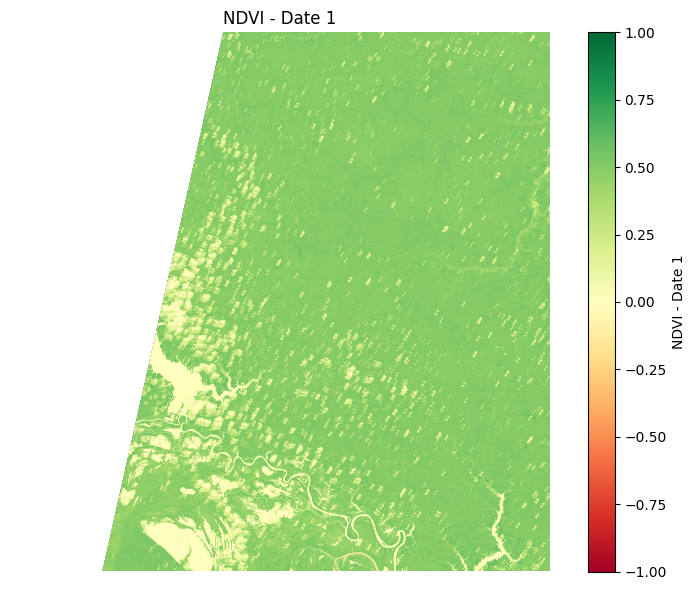

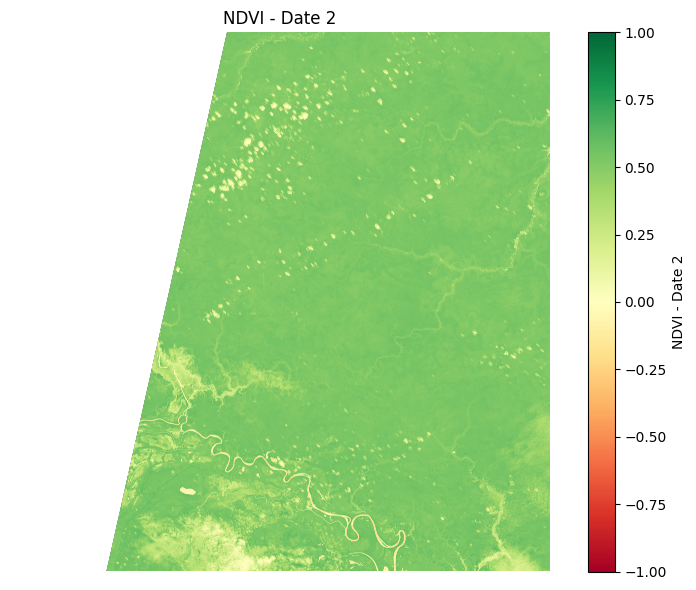

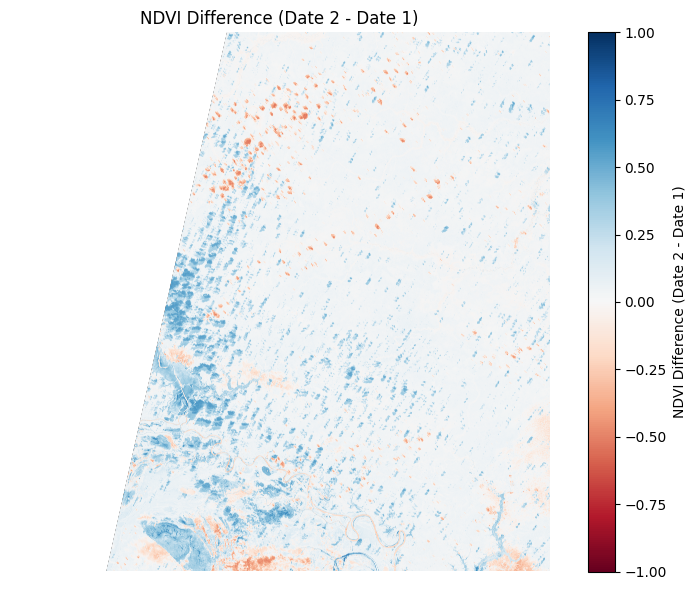

In [34]:
# ----------------------------
# Visualize and save results
# ----------------------------

plot_array(
    ndvi1,
    "NDVI - Date 1",
    FIG_DIR / "ndvi_date1.png",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
)

plot_array(
    ndvi2,
    "NDVI - Date 2",
    FIG_DIR / "ndvi_date2.png",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
)

plot_array(
    ndvi_diff,
    "NDVI Difference (Date 2 - Date 1)",
    FIG_DIR / "ndvi_difference.png",
    cmap="RdBu",
    vmin=-1,
    vmax=1,
)

## Interpretation

The two NDVI maps show vegetation conditions at the selected timestamps, while the difference map highlights areas of change.

In this prototype:
- negative NDVI differences may indicate possible vegetation loss
- positive differences may reflect regrowth or seasonal variation

This is intended as a compact proof-of-concept workflow rather than a full production monitoring system.

## Limitations and next steps

This notebook demonstrates a compact prototype workflow for ordering and analyzing Sentinel-2 data through UP42. Several production considerations would improve robustness further:

- Scene-level cloud filtering does not guarantee cloud-free pixels within the AOI.
- A production workflow should include cloud masking or scene-classification masking.
- Two-date NDVI differencing is a useful screening method, but observed changes may also reflect seasonality, water dynamics, or residual atmospheric effects.
- If scene extents or grids differ, explicit co-registration or resampling would be required before pixel-wise comparison.

Despite these limitations, the notebook demonstrates the core customer workflow:
1. discover data
2. order it
3. inspect it in STAC storage
4. retrieve the raster assets
5. compute an interpretable vegetation-change indicator
6. visualize the result

In [35]:
print("Workflow complete.")
print("Saved figures:")
for p in FIG_DIR.glob("*.png"):
    print("-", p.name)

Workflow complete.
Saved figures:
- ndvi_date2.png
- ndvi_difference.png
- ndvi_date1.png
